Importing all required tools

In [5]:
import numpy as np
import pandas as pd
import time

In [6]:
df = pd.read_csv("../data/sulfuric_acid_dataset.csv")

In [7]:
df.size

1400000

Checking whether Nan or 0 vales are present

In [8]:
missing_vals = df.isnull().sum()
print(missing_vals)

Feed_Temp_C       0
Feed_Press_bar    0
Feed_MassFlow     0
Feed_SO2          0
Feed_O2           0
Temp_F0_C         0
SO2_F0            0
SO3_F0            0
Temp_F10_C        0
SO2_F10           0
SO3_F10           0
Temp_F1_C         0
SO2_F1            0
SO3_F1            0
Temp_F20_C        0
SO2_F20           0
SO3_F20           0
Temp_F2_C         0
SO2_F2            0
SO3_F2            0
Temp_F30_C        0
SO2_F30           0
SO3_F30           0
Temp_F3_C         0
SO2_F3            0
SO3_F3            0
Temp_F40_C        0
SO2_F40           0
SO3_F40           0
Temp_F4_C         0
SO2_F4            0
SO3_F4            0
Temp_F50_C        0
SO2_F50           0
SO3_F50           0
dtype: int64


In [9]:
zero_vals = (df == 0).sum()
print(zero_vals[zero_vals > 0])

SO3_F0    40000
dtype: int64


In [10]:
df.columns

Index(['Feed_Temp_C', 'Feed_Press_bar', 'Feed_MassFlow', 'Feed_SO2', 'Feed_O2',
       'Temp_F0_C', 'SO2_F0', 'SO3_F0', 'Temp_F10_C', 'SO2_F10', 'SO3_F10',
       'Temp_F1_C', 'SO2_F1', 'SO3_F1', 'Temp_F20_C', 'SO2_F20', 'SO3_F20',
       'Temp_F2_C', 'SO2_F2', 'SO3_F2', 'Temp_F30_C', 'SO2_F30', 'SO3_F30',
       'Temp_F3_C', 'SO2_F3', 'SO3_F3', 'Temp_F40_C', 'SO2_F40', 'SO3_F40',
       'Temp_F4_C', 'SO2_F4', 'SO3_F4', 'Temp_F50_C', 'SO2_F50', 'SO3_F50'],
      dtype='str')

Assigning X and y as input and target variables

In [11]:
X = df[['Feed_Temp_C','Feed_Press_bar','Feed_MassFlow','Feed_SO2','Feed_O2']]
y = df[['Temp_F0_C', 'SO2_F0', 'SO3_F0', 'Temp_F10_C', 'SO2_F10', 'SO3_F10',
       'Temp_F1_C', 'SO2_F1', 'SO3_F1', 'Temp_F20_C', 'SO2_F20', 'SO3_F20',
       'Temp_F2_C', 'SO2_F2', 'SO3_F2', 'Temp_F30_C', 'SO2_F30', 'SO3_F30',
       'Temp_F3_C', 'SO2_F3', 'SO3_F3', 'Temp_F40_C', 'SO2_F40', 'SO3_F40',
       'Temp_F4_C', 'SO2_F4', 'SO3_F4', 'Temp_F50_C', 'SO2_F50', 'SO3_F50']]

Diving data into train ,test and validation

In [12]:
from sklearn.model_selection import train_test_split

X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size=0.15,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.1765,random_state=42)

intialising a list for storing evaluation results

In [13]:
evaluation_results = []

Training and Testing using Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

model_name_lr = 'Linear Regression'

model_lr = make_pipeline(StandardScaler(),LinearRegression())
start_time_lr = time.time()
model_lr.fit(X_train,y_train)
total_train_lr = time.time()-start_time_lr

start_time_lr = time.time()
y_pred = model_lr.predict(X_test)
total_test_lr = time.time() - start_time_lr

r2_lr = r2_score(y_test,y_pred,multioutput='uniform_average')
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lr = mean_absolute_error(y_test,y_pred)

evaluation_results.append({
    "Model": model_name_lr,
    "R2 Score": r2_lr,
    "RMSE": rmse_lr,
    "MAE": mae_lr,
    "Train Time (s)": total_train_lr,
    "Inference Time (s)": total_test_lr
})

Training and Testing using Ridge Regression

In [15]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

model_name_rr = 'Ridge Regression'

model_rr = make_pipeline(StandardScaler(),Ridge(alpha=1.0))
start_time_rr = time.time()
model_rr.fit(X_train,y_train)
total_train_rr = time.time()-start_time_rr

start_time_rr = time.time()
y_pred = model_rr.predict(X_test)
total_test_rr = time.time() - start_time_rr

r2_rr = r2_score(y_test,y_pred,multioutput='uniform_average')
rmse_rr = np.sqrt(mean_squared_error(y_test, y_pred))
mae_rr = mean_absolute_error(y_test,y_pred)

evaluation_results.append({
    "Model": model_name_rr,
    "R2 Score": r2_rr,
    "RMSE": rmse_rr,
    "MAE": mae_rr,
    "Train Time (s)": total_train_rr,
    "Inference Time (s)": total_test_rr
})

Training and Testing using Random Forest Regression

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

model_name_rfr = 'Random Forest Regressor'

r2_best = -float('inf')
best_depth=None

for depth in [10,20,30,None]:
    model_rfr_temp = make_pipeline(StandardScaler(),RandomForestRegressor(n_estimators=200,max_depth=depth,random_state=42,n_jobs=-1))
    model_rfr_temp.fit(X_train,y_train)
    y_val_pred = model_rfr_temp.predict(X_val)
    r2_val = r2_score(y_val,y_val_pred,multioutput='uniform_average')
    if r2_val>r2_best:
        r2_best=r2_val
        best_depth=depth

model_rfr = make_pipeline(StandardScaler(),RandomForestRegressor(n_estimators=200,max_depth=best_depth,random_state=42,n_jobs=-1))

start_time_rfr = time.time()
model_rfr.fit(X_train,y_train)
total_train_rfr = time.time()-start_time_rfr

start_time_rfr = time.time()
y_pred = model_rfr.predict(X_test)
total_test_rfr = time.time()-start_time_rfr

r2_rfr = r2_score(y_test,y_pred,multioutput='uniform_average')
rmse_rfr = np.sqrt(mean_squared_error(y_test, y_pred))
mae_rfr = mean_absolute_error(y_test,y_pred)

evaluation_results.append({
    "Model": model_name_rfr,
    "R2 Score": r2_rfr,
    "RMSE": rmse_rfr,
    "MAE": mae_rfr,
    "Train Time (s)": total_train_rfr,
    "Inference Time (s)": total_test_rfr
})


Training and Testing using XGBoost Regression

In [17]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_name_xgb = 'XGBoost Regressor'

r2_best_xgb = -float('inf')
best_lr = None
for lr in [0.05, 0.1, 0.2]:
    model_xgb_temp = make_pipeline(StandardScaler(), XGBRegressor(learning_rate=lr, n_estimators=100, random_state=42, n_jobs=-1))
    model_xgb_temp.fit(X_train, y_train)
    y_val_pred_xgb = model_xgb_temp.predict(X_val)
    r2_val_xgb = r2_score(y_val, y_val_pred_xgb, multioutput='uniform_average')
    
    if r2_val_xgb > r2_best_xgb:
        r2_best_xgb = r2_val_xgb
        best_lr = lr
model_xgb = make_pipeline(StandardScaler(), XGBRegressor(learning_rate=best_lr, n_estimators=100, random_state=42, n_jobs=-1))

start_time_xgb = time.time()
model_xgb.fit(X_train, y_train)
total_train_xgb = time.time() - start_time_xgb

start_time_xgb = time.time()
y_pred_xgb = model_xgb.predict(X_test)
total_test_xgb = time.time() - start_time_xgb

r2_xgb = r2_score(y_test, y_pred_xgb, multioutput='uniform_average')
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

evaluation_results.append({
    "Model": model_name_xgb,
    "R2 Score": r2_xgb,
    "RMSE": rmse_xgb,
    "MAE": mae_xgb,
    "Train Time (s)": total_train_xgb,
    "Inference Time (s)": total_test_xgb
})

Comparing the results from all models

In [19]:
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print(results_df)

                     Model  R2 Score      RMSE       MAE  Train Time (s)  \
0  Random Forest Regressor  0.999970  0.061127  0.014721        9.796708   
1         Ridge Regression  0.999947  0.076557  0.016595        0.048776   
2        Linear Regression  0.999947  0.076552  0.016579        0.202164   
3        XGBoost Regressor  0.991219  0.089472  0.016525        6.402982   

   Inference Time (s)  
0            0.391957  
1            0.005336  
2            0.006051  
3            0.090212  


Plotting between actual v/s predicted

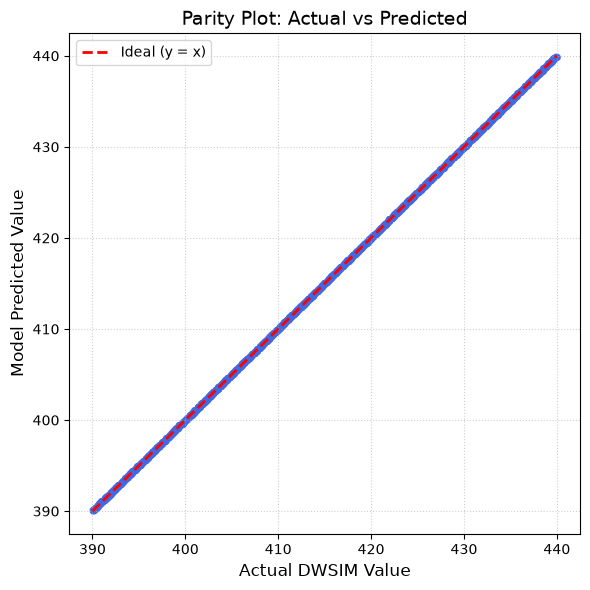

In [20]:
import matplotlib.pyplot as plt

# Choose which output column index to plot (e.g., index 0 for your first target variable)
target_idx = 0 

# Extract the specific target column (handles both Pandas DataFrames and NumPy arrays)
y_true_col = y_test.iloc[:, target_idx] if hasattr(y_test, 'iloc') else y_test[:, target_idx]
y_pred_col = y_pred_rfr.iloc[:, target_idx] if hasattr(y_pred_xgb, 'iloc') else y_pred_xgb[:, target_idx]

plt.figure(figsize=(6, 6))

# Scatter plot of actual vs predicted values
plt.scatter(y_true_col, y_pred_col, alpha=0.4, color='royalblue', s=15)

# Draw the ideal 45-degree reference line (y = x)
min_val = min(y_true_col.min(), y_pred_col.min())
max_val = max(y_true_col.max(), y_pred_col.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal (y = x)')

plt.xlabel('Actual DWSIM Value', fontsize=12)
plt.ylabel('Model Predicted Value', fontsize=12)
plt.title('Parity Plot: Actual vs Predicted', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Testing with random values

In [21]:
import pandas as pd

# Custom outside operating condition (using mole fractions)
custom_input = pd.DataFrame({
    'Feed_Temp_C': [425.0],
    'Feed_Press_bar': [1.3],
    'Feed_MassFlow': [3600.0],
    'Feed_SO2': [0.090909091],  # 10.5% mole fraction
    'Feed_O2': [0.1010101]    # 12.0% mole fraction
})

# Predict all 30 outputs instantly
custom_pred = model_rfr.predict(custom_input)
custom_results = pd.Series(custom_pred[0], index=y.columns)

print(custom_results)

Temp_F0_C     425.003036
SO2_F0          0.090861
SO3_F0          0.000000
Temp_F10_C    593.597106
SO2_F10         0.034333
SO3_F10         0.059218
Temp_F1_C     430.000000
SO2_F1          0.034333
SO3_F1          0.059218
Temp_F20_C    500.711322
SO2_F20         0.009803
SO3_F20         0.084916
Temp_F2_C     440.000000
SO2_F2          0.009803
SO3_F2          0.084916
Temp_F30_C    457.307267
SO2_F30         0.003736
SO3_F30         0.091271
Temp_F3_C     430.000000
SO2_F3          0.003736
SO3_F3          0.091271
Temp_F40_C    440.112536
SO2_F40         0.000183
SO3_F40         0.094993
Temp_F4_C     420.000000
SO2_F4          0.000183
SO3_F4          0.094993
Temp_F50_C    420.261242
SO2_F50         0.000092
SO3_F50         0.095089
dtype: float64


Feature Importance

In [22]:
## accessing the model from pipeline
rf_model = model_rfr.named_steps['randomforestregressor']

## using inbuit function to find the importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

## combining them into a dataframe

feature_imp = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)

feature_imp


,Feature,Importance
3,Feed_SO2,0.710206
0,Feed_Temp_C,0.289712
4,Feed_O2,0.000034
2,Feed_MassFlow,0.000024
1,Feed_Press_bar,0.000024


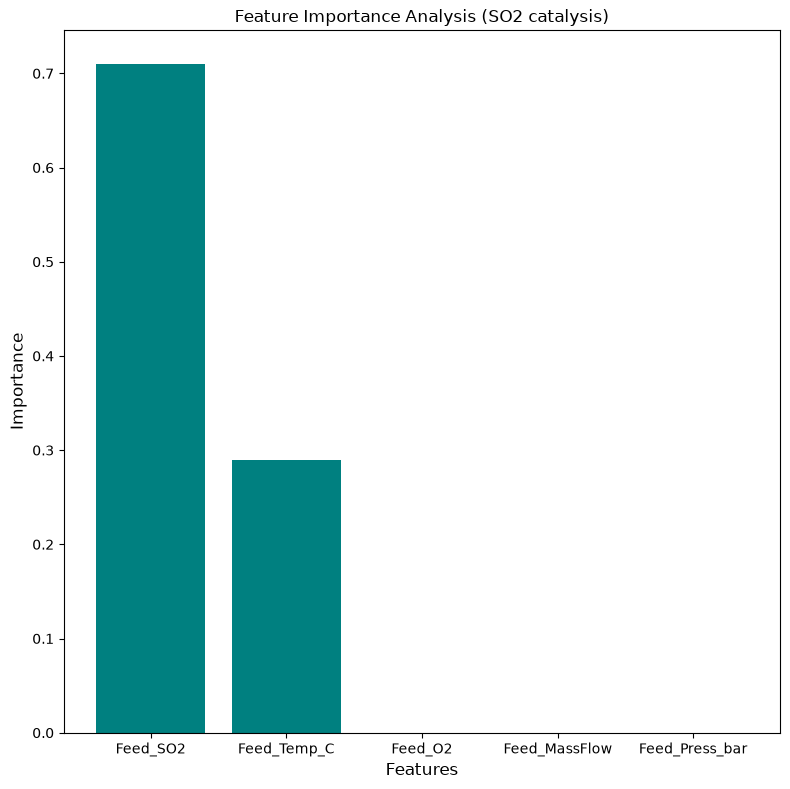

In [23]:
plt.figure(figsize=(8,8))
plt.bar(feature_imp['Feature'],feature_imp['Importance'],color='teal')
plt.xlabel('Features',fontsize=12)
plt.ylabel('Importance',fontsize=12)
plt.title("Feature Importance Analysis (SO2 catalysis)")
plt.tight_layout()
plt.show()

By observing we can say that feed SO2 (i.e SO2 mole fraction) is the primary factor and feed Temperature is the secondary factor

Since among all the model Random Forest Regressor have the best r2_score , so lets store it in file , sso that we can access easily

In [24]:
import joblib

joblib.dump(model_rfr,"sulfuric_acid_rfr_surrogate.pkl")
print("Model successfully stored")

##accessing
model = joblib.load("sulfuric_acid_rfr_surrogate.pkl")
print("Loaded Model successfully")
## predicted = model.predict(X)

# Save your target column names to a file
joblib.dump(y.columns.tolist(), 'target_columns.pkl')
print("Target column names saved!")

Model successfully stored
Loaded Model successfully
Target column names saved!


In [25]:
sample_test = pd.DataFrame({
    'Feed_Temp_C':[425.00],
    'Feed_Press_bar':[1.2],
    'Feed_MassFlow':[300.00], 
    'Feed_SO2':[0.10], 
    'Feed_O2':[0.12]
})
print("Inputs being passed to model:", sample_test)
y_predicted = model.predict(sample_test)



Inputs being passed to model:    Feed_Temp_C  Feed_Press_bar  Feed_MassFlow  Feed_SO2  Feed_O2
0        425.0             1.2          300.0       0.1     0.12


In [26]:
y_predicted

array([[4.24988032e+02, 9.99060880e-02, 0.00000000e+00, 6.08818977e+02,
        3.78627780e-02, 6.53055546e-02, 4.30000000e+02, 3.78627780e-02,
        6.53055546e-02, 5.07154919e+02, 1.08244388e-02, 9.37655734e-02,
        4.40000000e+02, 1.08244388e-02, 9.37655734e-02, 4.58857095e+02,
        4.12713593e-03, 1.00815022e-01, 4.30000000e+02, 4.12713593e-03,
        1.00815022e-01, 4.41042720e+02, 2.02627240e-04, 1.04945881e-01,
        4.20000000e+02, 2.02627240e-04, 1.04945881e-01, 4.20285280e+02,
        1.01318955e-04, 1.05052517e-01]])

In [27]:
y.columns

Index(['Temp_F0_C', 'SO2_F0', 'SO3_F0', 'Temp_F10_C', 'SO2_F10', 'SO3_F10',
       'Temp_F1_C', 'SO2_F1', 'SO3_F1', 'Temp_F20_C', 'SO2_F20', 'SO3_F20',
       'Temp_F2_C', 'SO2_F2', 'SO3_F2', 'Temp_F30_C', 'SO2_F30', 'SO3_F30',
       'Temp_F3_C', 'SO2_F3', 'SO3_F3', 'Temp_F40_C', 'SO2_F40', 'SO3_F40',
       'Temp_F4_C', 'SO2_F4', 'SO3_F4', 'Temp_F50_C', 'SO2_F50', 'SO3_F50'],
      dtype='str')